=== Dataset Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1950 entries, 0 to 1949
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              1950 non-null   datetime64[ns]
 1   Ticker            1950 non-null   object        
 2   Open              1950 non-null   float64       
 3   High              1950 non-null   float64       
 4   Low               1950 non-null   float64       
 5   Close             1950 non-null   float64       
 6   Adj Close         1950 non-null   float64       
 7   Volume            1950 non-null   int64         
 8   Daily Return (%)  1945 non-null   float64       
 9   MA20              1855 non-null   float64       
 10  MA50              1705 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(1), object(1)
memory usage: 167.7+ KB
None

First 5 Rows:
        Date Ticker    Open    High     Low   Close  Adj Close  

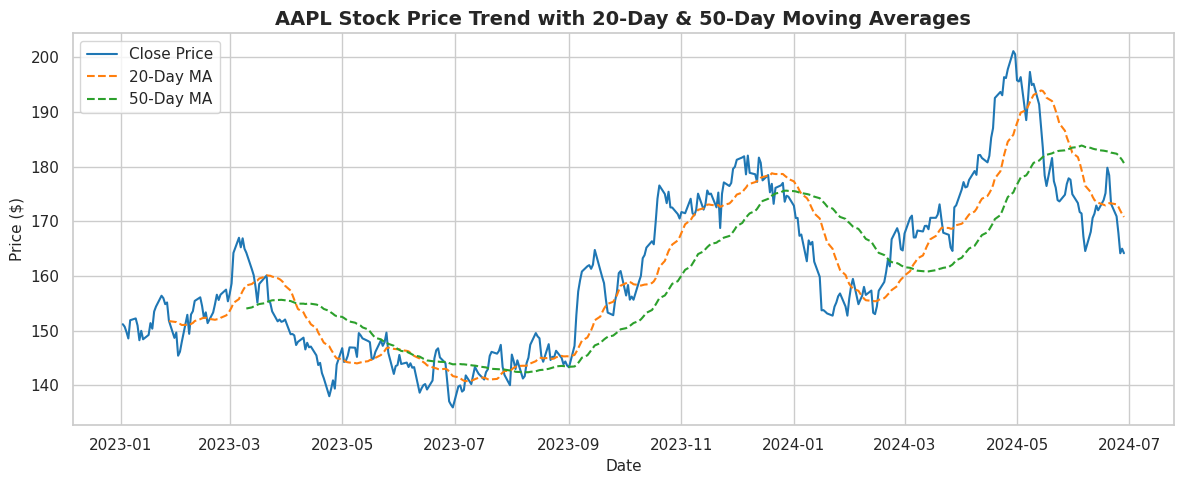

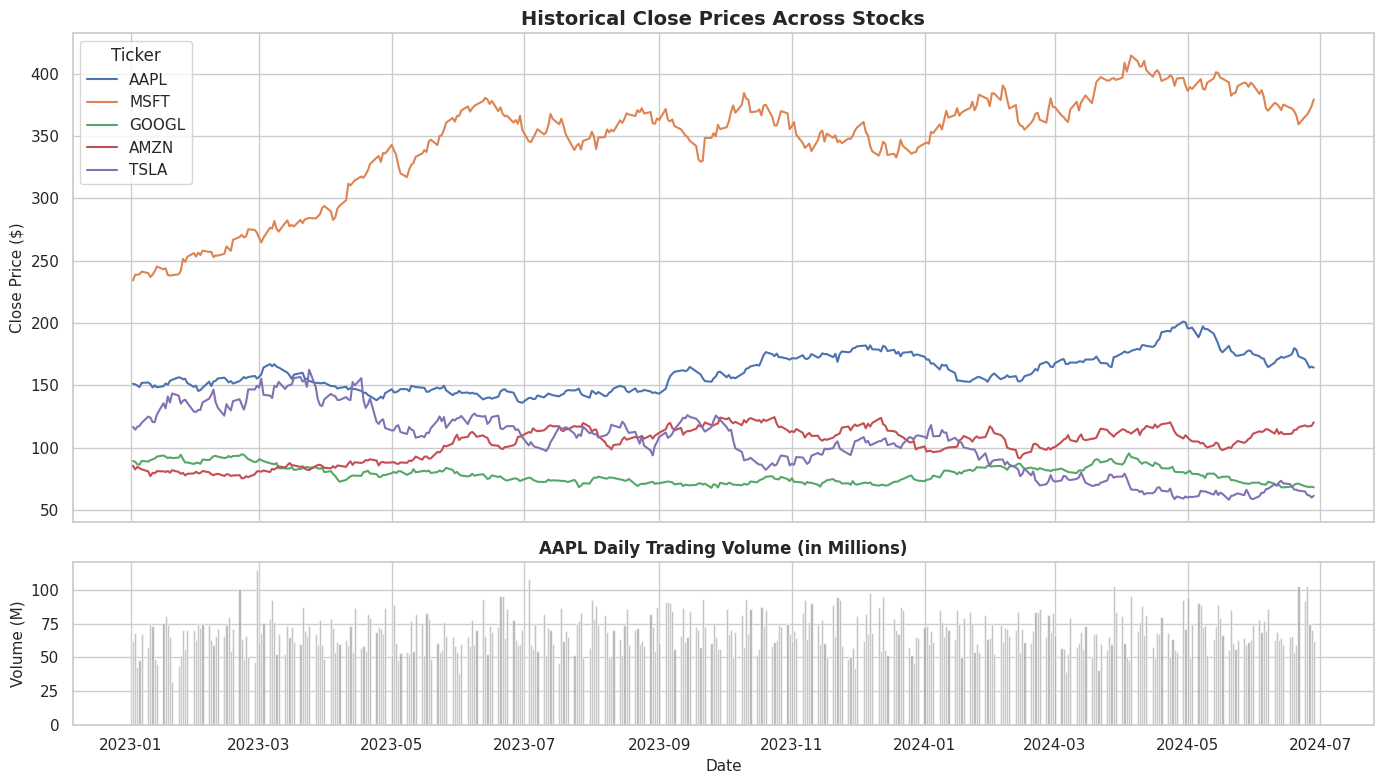

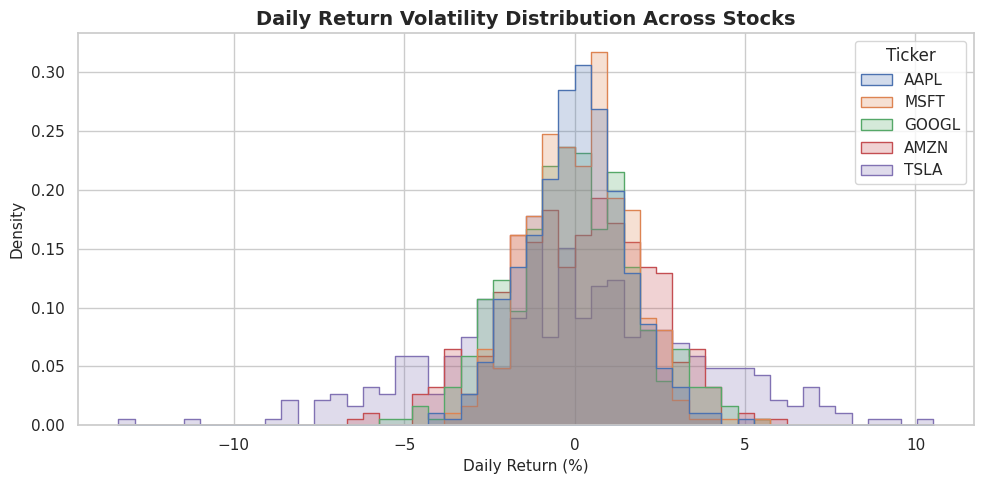

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Load Dataset
df = pd.read_csv("stock_market_analysis.csv")
df["Date"] = pd.to_datetime(df["Date"])

# Display basic dataset summary
print("=== Dataset Summary ===")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

# 2. Historical Price Trend with Moving Averages (AAPL Example)
aapl_df = df[df["Ticker"] == "AAPL"].copy()

plt.figure(figsize=(12, 5))
plt.plot(
    aapl_df["Date"],
    aapl_df["Close"],
    label="Close Price",
    color="#1f77b4",
    linewidth=1.5,
)
plt.plot(
    aapl_df["Date"],
    aapl_df["MA20"],
    label="20-Day MA",
    color="#ff7f0e",
    linestyle="--",
    linewidth=1.5,
)
plt.plot(
    aapl_df["Date"],
    aapl_df["MA50"],
    label="50-Day MA",
    color="#2ca02c",
    linestyle="--",
    linewidth=1.5,
)

plt.title(
    "AAPL Stock Price Trend with 20-Day & 50-Day Moving Averages",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Date", fontsize=11)
plt.ylabel("Price ($)", fontsize=11)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# 3. Multi-Stock Close Price Trends & Trading Volume Comparison
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

# Top Subplot: Close prices for all stock tickers
sns.lineplot(data=df, x="Date", y="Close", hue="Ticker", ax=ax1, linewidth=1.5)
ax1.set_title(
    "Historical Close Prices Across Stocks", fontsize=14, fontweight="bold"
)
ax1.set_ylabel("Close Price ($)", fontsize=11)

# Bottom Subplot: Trading volume bar chart for AAPL
ax2.bar(
    aapl_df["Date"],
    aapl_df["Volume"] / 1e6,
    color="#7f7f7f",
    alpha=0.6,
    width=1,
)
ax2.set_title(
    "AAPL Daily Trading Volume (in Millions)", fontsize=12, fontweight="bold"
)
ax2.set_xlabel("Date", fontsize=11)
ax2.set_ylabel("Volume (M)", fontsize=11)

plt.tight_layout()
plt.show()

# 4. Daily Return Distribution & Volatility Analysis
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Daily Return (%)",
    hue="Ticker",
    element="step",
    stat="density",
    common_norm=False,
    bins=50,
)
plt.title(
    "Daily Return Volatility Distribution Across Stocks",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Daily Return (%)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.tight_layout()
plt.show()